DSC550
Hess
6/29/2025
Week 4

In this exercise, you will build a linear regression model to predict fuel efficiency (miles per gallon) of automobiles. Download the auto-mpg.csv dataset from: Auto-mpg dataset. 
1.	Load the data as a Pandas data frame and ensure that it imported correctly.


In [ ]:
import pandas as pd

#import the CSV
df = pd.read_csv("C:\\Users\\hessk\\OneDrive\\Desktop\\DSC550\\auto-mpg.csv")

#display the first few rows to make sure it imported properly, and see the type of data that was imported
print(df.head())
print(df.info())

2.	Begin by prepping the data for modeling:
o	Remove the car name column.


In [4]:
#drop car name column, and print a couple rows to ensure it dropped
df = df.drop(columns=['car name'])

print(df.head)

<bound method NDFrame.head of       mpg  cylinders  displacement horsepower  weight  acceleration  \
0    18.0          8         307.0        130    3504          12.0   
1    15.0          8         350.0        165    3693          11.5   
2    18.0          8         318.0        150    3436          11.0   
3    16.0          8         304.0        150    3433          12.0   
4    17.0          8         302.0        140    3449          10.5   
..    ...        ...           ...        ...     ...           ...   
393  27.0          4         140.0         86    2790          15.6   
394  44.0          4          97.0         52    2130          24.6   
395  32.0          4         135.0         84    2295          11.6   
396  28.0          4         120.0         79    2625          18.6   
397  31.0          4         119.0         82    2720          19.4   

     model year  origin  
0            70       1  
1            70       1  
2            70       1  
3            

o	The horsepower column values likely imported as a string data type. Figure out why and replace any strings with the column mean.

The horsepower column was possibly converted to string because data could have been typed in, or NA, or ? added to the dataset. So conversion errors dont happen, it was read in as a string instead. This is a common feature of it. 

In [6]:
import numpy as np

#convert horsepower to numeric, and replace errors to NaN
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

In [18]:
#Calculate the mean of horsepower
mean_hp = df['horsepower'].mean()
print(mean_hp)

104.46938775510203


In [10]:
#fill in NaN with the mean that was calculated
df['horsepower'] = df['horsepower'].fillna(mean_hp)

In [12]:
print(df['horsepower'])

0      130.0
1      165.0
2      150.0
3      150.0
4      140.0
       ...  
393     86.0
394     52.0
395     84.0
396     79.0
397     82.0
Name: horsepower, Length: 398, dtype: float64


o	Create dummy variables for the origin column.

In [20]:
#create dummy variables with the origin column
df = pd.get_dummies(df, columns=['origin'], prefix='origin')

3.	Create a correlation coefficient matrix and/or visualization. Are there features highly correlated with mpg?

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

#create the correlation matrix
corr_matrix = df.corr()

print(corr_matrix)

                   mpg  cylinders  displacement  horsepower    weight  \
mpg           1.000000  -0.775396     -0.804203   -0.771437 -0.831741   
cylinders    -0.775396   1.000000      0.950721    0.838939  0.896017   
displacement -0.804203   0.950721      1.000000    0.893646  0.932824   
horsepower   -0.771437   0.838939      0.893646    1.000000  0.860574   
weight       -0.831741   0.896017      0.932824    0.860574  1.000000   
acceleration  0.420289  -0.505419     -0.543684   -0.684259 -0.417457   
model year    0.579267  -0.348746     -0.370164   -0.411651 -0.306564   
origin_1     -0.568192   0.604351      0.651407    0.486083  0.598398   
origin_2      0.259022  -0.352861     -0.373886   -0.281258 -0.298843   
origin_3      0.442174  -0.396479     -0.433505   -0.321325 -0.440817   

              acceleration  model year  origin_1  origin_2  origin_3  
mpg               0.420289    0.579267 -0.568192  0.259022  0.442174  
cylinders        -0.505419   -0.348746  0.604351 -0.35

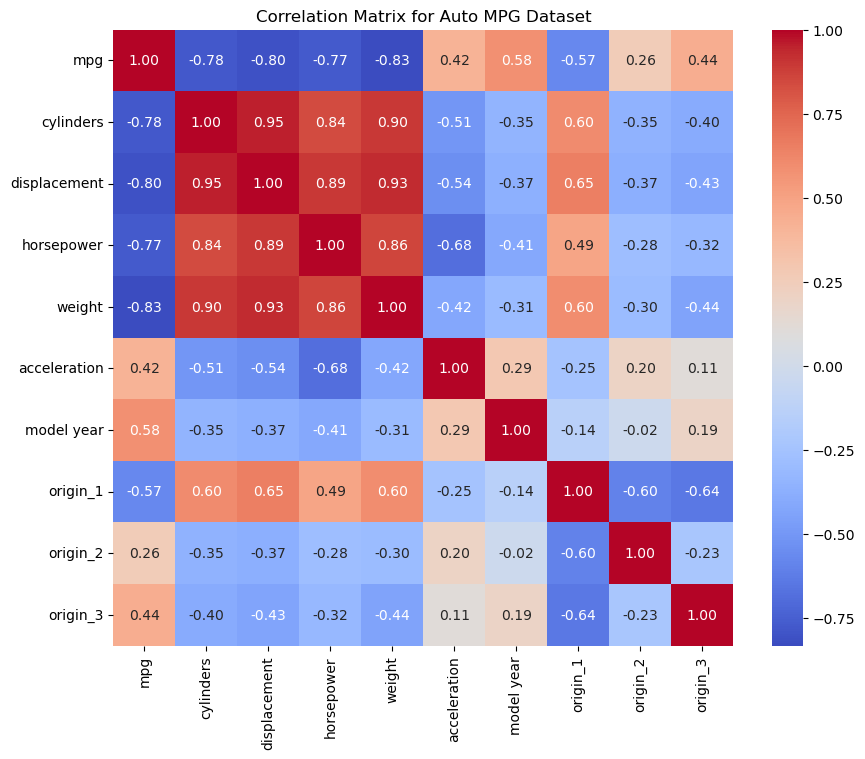

In [24]:
#display with heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix for Auto MPG Dataset')
plt.show()

4.	Plot mpg versus weight. Analyze this graph and explain how it relates to the corresponding correlation coefficient.

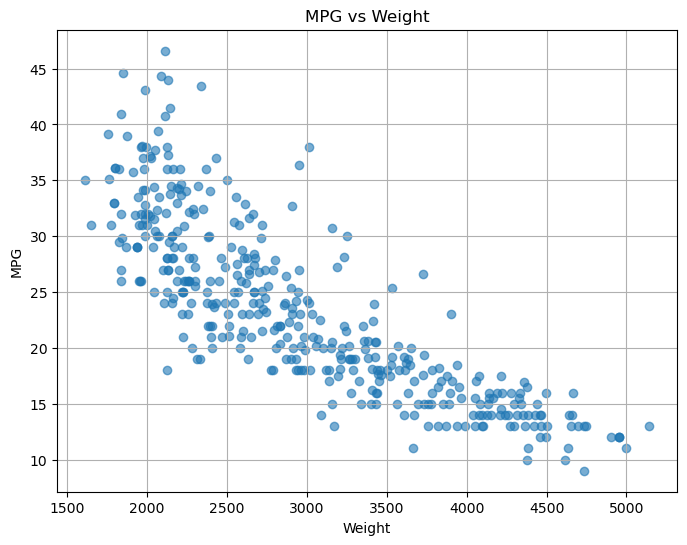

In [28]:
# Plot mpg vs weight
plt.figure(figsize=(8,6))
plt.scatter(df['weight'], df['mpg'], alpha=0.6)
plt.xlabel('Weight')
plt.ylabel('MPG')
plt.title('MPG vs Weight')
plt.grid(True)
plt.show()

In [32]:
#calculate and print the correlation coefficient
corr = df['mpg'].corr(df['weight'])
print(f"Correlation coefficient - mpg and weight: {corr:.2f}")

Correlation coefficient - mpg and weight: -0.83


5.	Randomly split the data into 80% training data and 20% test data, where your target is mpg.

In [34]:
from sklearn.model_selection import train_test_split

#split the features and target mpg
X = df.drop(columns=['mpg'])
y = df['mpg']

In [35]:
#train and test sets 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

6.	Train an ordinary linear regression on the training data.

In [38]:
from sklearn.linear_model import LinearRegression

#train the model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [40]:
#print coefficients and intercept
print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)
print("Feature names:", X_train.columns.tolist())

Intercept: -20.20266022523066
Coefficients: [-0.16373048  0.01958399 -0.01334457 -0.00707275  0.07335016  0.82739747
 -1.86404853  1.07519552  0.78885302]
Feature names: ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model year', 'origin_1', 'origin_2', 'origin_3']


7.	Calculate R2, RMSE, and MAE on both the training and test sets and interpret your results.

In [42]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

#predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)


In [44]:
#metrics
def print_metrics(y_true, y_pred, dataset_name):
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    print(f"{dataset_name} set metrics:")
    print(f"  R^2  = {r2:.3f}")
    print(f"  RMSE = {rmse:.3f}")
    print(f"  MAE  = {mae:.3f}\n")

print_metrics(y_train, y_train_pred, "Training")
print_metrics(y_test, y_test_pred, "Test")

Training set metrics:
  R^2  = 0.819
  RMSE = 3.370
  MAE  = 2.605

Test set metrics:
  R^2  = 0.845
  RMSE = 2.888
  MAE  = 2.288



R2 - Both training and test are high, and relitively close to eachother. There is 82-85% of the variance in MPG for both are seen. The random sampling can explain the difference between the train and test. The model is not overfit or underfit. 
RMSE - shows the prediciton error in MPG. Since the the test error rate is lower, it is a good sign.
MAE - The error in predicted MPG. Both test and train are low and similar, which also shows its a good model. 
Since the numbers are similar, and error is low, it shows this model is a good fit for this dataset. 

8.	Pick another regression model and repeat the previous two steps. Note: Do NOT choose logistic regression as it is more like a classification model.

In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

#using ridge regression model, test and train the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

Ridge()

In [24]:
#predictions
y_train_pred = ridge.predict(X_train)
y_test_pred = ridge.predict(X_test)

In [26]:
#calculate for training set
r2_train = r2_score(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
mae_train = mean_absolute_error(y_train, y_train_pred)

#calculate for test set
r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test = mean_absolute_error(y_test, y_test_pred)

print(f"Training set: R^2 = {r2_train:.3f}, RMSE = {rmse_train:.3f}, MAE = {mae_train:.3f}")
print(f"Test set:     R^2 = {r2_test:.3f}, RMSE = {rmse_test:.3f}, MAE = {mae_test:.3f}")

Training set: R^2 = 0.814, RMSE = 3.415, MAE = 2.599
Test set:     R^2 = 0.847, RMSE = 2.864, MAE = 2.254


The Ridge Regression and Linear regression are very similar and have similar results.
The model again reflects the test set to be slightly higher than the training set, again displaying that the model is not over or under fit. With an R2 over 80% it has a strong predicting power. And the error rates are low and both are very similar meaning the predictions are generally accurate. 